# Python Operational Analytics – NorthStar Urban Mobility and Logistics

## Objective
This notebook uses Python analytics techniques to identify operational inefficiencies, customer dissatisfaction patterns, operational cost escalation, and service instability across NorthStar’s delivery systems.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import files

uploaded = files.upload()

Saving complaints.csv to complaints.csv
Saving deliveries.csv to deliveries.csv
Saving incidents.csv to incidents.csv


In [3]:
deliveries = pd.read_csv("deliveries.csv")
complaints = pd.read_csv("complaints.csv")
incidents = pd.read_csv("incidents.csv")

In [4]:
deliveries.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22


## Dataset Exploration

The operational datasets contain delivery records, complaint histories, and operational incident information used to evaluate service quality, operational instability, and financial impact across NorthStar’s systems.

## KPI Analysis 1 – Operational Hub Performance

### Objective
Identify operational hubs associated with elevated route override activity and reduced customer satisfaction.

In [5]:
hub_kpis = deliveries.groupby("hub_id").agg({
    "manual_route_override_count":"mean",
    "customer_rating_post_delivery":"mean",
    "fuel_or_charge_cost":"mean"
}).round(2)

hub_kpis

,manual_route_override_count,customer_rating_post_delivery,fuel_or_charge_cost
hub_id,,,
H01,1.03,3.84,12.76
H02,0.92,3.95,12.57
H03,0.89,3.90,12.74
H04,0.87,3.92,13.17
H05,0.95,3.67,13.69
H06,0.91,3.88,13.32
H07,1.05,3.88,12.92
H08,1.11,3.88,11.71


## Interpretation

Several operational hubs demonstrated elevated route override activity combined with lower customer ratings and increased operational costs.

This suggests that operational inefficiencies may be geographically concentrated within specific regional hubs.

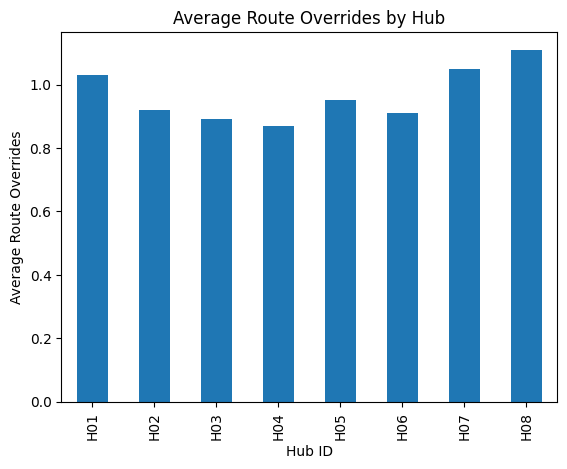

In [6]:
hub_kpis["manual_route_override_count"].plot(kind="bar")

plt.title("Average Route Overrides by Hub")
plt.ylabel("Average Route Overrides")
plt.xlabel("Hub ID")

plt.show()

## KPI Analysis 2 – Complaint Severity and Compensation

### Objective
Analyse the financial impact of customer complaints across different complaint categories.

In [7]:
complaint_kpis = complaints.groupby("complaint_type").agg({
    "compensation_amount":"mean",
    "resolution_days":"mean"
}).round(2)

complaint_kpis

,compensation_amount,resolution_days
complaint_type,,
AppIssue,19.61,8.60
Billing,23.87,7.75
Damage,23.98,11.33
Delay,18.05,7.26
DriverBehaviour,21.15,8.16
MissedPickup,22.59,7.64
SupportExperience,17.12,7.45


## Interpretation

Several complaint categories demonstrated elevated compensation costs and longer resolution times, suggesting that operational service failures contribute directly to financial and customer-service challenges.

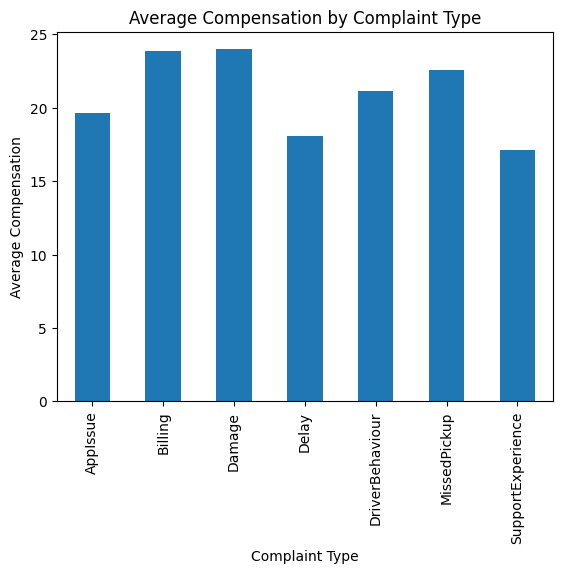

In [8]:
complaint_kpis["compensation_amount"].plot(kind="bar")

plt.title("Average Compensation by Complaint Type")
plt.ylabel("Average Compensation")
plt.xlabel("Complaint Type")

plt.show()

## KPI Analysis 3 – Incident Severity and Resolution Performance

### Objective
Evaluate operational incident severity and incident-resolution efficiency.

In [9]:
incident_kpis = incidents.groupby("severity").agg({
    "resolved_hours":"mean"
}).round(2)

incident_kpis

,resolved_hours
severity,
Critical,11.44
High,11.15
Low,13.58
Medium,11.47


## Interpretation

Higher-severity operational incidents demonstrated extended resolution times, suggesting that major operational disruptions require substantial recovery effort and resource allocation.

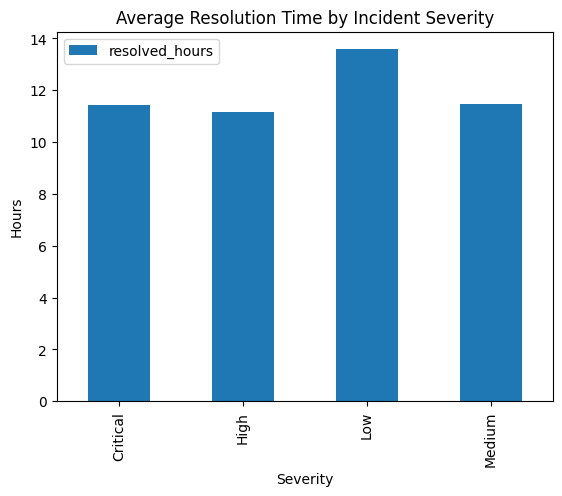

In [10]:
incident_kpis.plot(kind="bar")

plt.title("Average Resolution Time by Incident Severity")
plt.ylabel("Hours")
plt.xlabel("Severity")

plt.show()

## KPI Analysis 4 – Proof of Completion Failures

### Objective
Identify operational compliance issues linked to missing proof-of-completion records.

In [11]:
proof_kpis = deliveries.groupby("hub_id").agg({
    "proof_of_completion_missing":"sum"
})

proof_kpis

,proof_of_completion_missing
hub_id,
H01,6
H02,8
H03,9
H04,7
H05,10
H06,10
H07,9
H08,10


## Interpretation

Several operational hubs demonstrated elevated proof-of-completion failures, suggesting operational compliance weaknesses and potential service-verification issues.

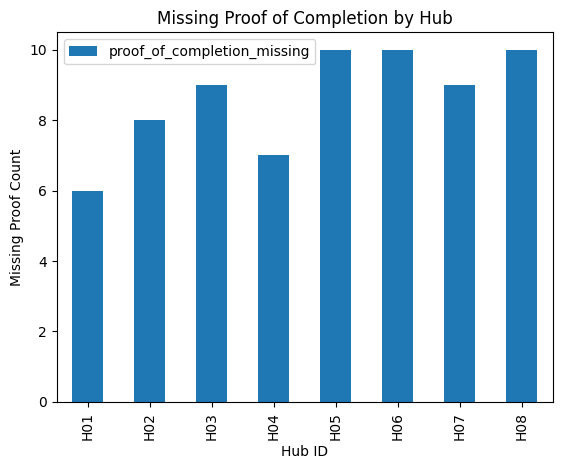

In [12]:
proof_kpis.plot(kind="bar")

plt.title("Missing Proof of Completion by Hub")
plt.ylabel("Missing Proof Count")
plt.xlabel("Hub ID")

plt.show()

# Final Python Analytics Discussion

The Python analytics identified several major operational performance issues across NorthStar’s systems.

Key findings include:

- geographically concentrated operational inefficiencies
- elevated customer dissatisfaction
- increased compensation costs
- operational incident severity patterns
- proof-of-completion compliance failures

The findings demonstrate that operational instability affects service quality, customer experience, and financial performance simultaneously.

The analysis also highlights the importance of integrating operational, complaint, and incident datasets to improve organisational visibility and decision-making.